In [317]:
!pip install -qU  duckduckgo-search langchain-community


In [318]:
!pip install langchain-groq


In [319]:
!pip install -U ddgs

In [320]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")
from langchain_groq import ChatGroq
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="qwen/qwen3.6-27b",
    temperature=0.7,
)

# Tools

## DUCKDUCKGOSEARCH TOOL

In [321]:
from  langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool          # ← add this line

@tool
def search_duckduckgo(query:str) ->str:
  """This tool search the latest news on DuckDuckGo for the given query  and returns the results"""
  duck_search = DuckDuckGoSearchRun()
  return duck_search.invoke(query)
#duck_search = DuckDuckGoSearchRun()
#duck_search.invoke("Tranding News About LangChain and LangGraph ")

### so this answer not generated by llm there is no llm involed in the above code ,this response directly get from duckduckgosearchRun


###So if my llm  dosen't have any latest information ,latest knowledge about any topic  I can use this tool to get the latest information then I can provide  this to LLM,then LLM use this information ,that provide the run time information during llm calls

# ARXIV Query Tool

In [322]:
!pip install pymupdf

In [323]:
!pip install -q -U langchain_community

In [324]:
!pip show arxiv | grep Version

Version: 4.0.1


In [325]:
!pip uninstall -y arxiv
!pip install -q "arxiv==1.4.8"
!pip install -q -U arxiv

Found existing installation: arxiv 4.0.1
Uninstalling arxiv-4.0.1:
  Successfully uninstalled arxiv-4.0.1


In [326]:
import arxiv
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun
from langchain.tools import tool
@tool
def arxiv_tool(query:str)->str:
  """Use this tool to search for papers on Arxiv."""
  arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
  return arxiv_query.invoke(query)
"""
# Restore Search.results() using the new Client-based API (which correctly uses https)
_client = arxiv.Client()

def _patched_results(self, offset=0):
    return _client.results(self, offset=offset)

arxiv.Search.results = _patched_results

# Confirm it's using https now
print(arxiv.Client)  # sanity check import works

arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
result = arxiv_query.invoke("Transformer models in NLP")
print(result)"""

'\n# Restore Search.results() using the new Client-based API (which correctly uses https)\n_client = arxiv.Client()\n\ndef _patched_results(self, offset=0):\n    return _client.results(self, offset=offset)\n\narxiv.Search.results = _patched_results\n\n# Confirm it\'s using https now\nprint(arxiv.Client)  # sanity check import works\n\narxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())\nresult = arxiv_query.invoke("Transformer models in NLP")\nprint(result)'

# Wikipedia Search Tool

In [327]:
!pip install wikipedia

In [328]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.tools import tool
@tool
def wiki_tool(query:str):
  """Use this tool to get information from Wikipedia."""
  wiki_query=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
  return wiki_query.invoke(query)
#wiki_query=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
#wiki_query.invoke("what is Langraph")

# Custom Tool

In [329]:
from langchain.tools import tool
@tool
def person_info_tool(name:str):
   """Use this custom tool to get personal information about Alice,Bob,Charlie."""
   info={
       "Alice":"Alice is a software engineer with 5 years of experience in AI.",
       "Bob":"Bob is a data scientist who loves working with large datasets.",
       "Charlie":"Charlie is a product manager with a background in tech startups."
   }

   return info.get(name,"No information avaiable for this person.")

In [330]:
person_info_tool.invoke("Alice")

'Alice is a software engineer with 5 years of experience in AI.'

# Tool Binding with LLM

In [331]:
tools=[search_duckduckgo,arxiv_tool,person_info_tool]
llm_with_tools=llm.bind_tools(tools)

In [332]:
from google.colab import userdata
from langchain_groq import ChatGroq

# Ensure groq_api_key is available from the kernel state
# groq_api_key = userdata.get("GROQ_API_KEY")

# Re-initialize llm with a max_tokens limit to avoid rate limit error
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="qwen/qwen3.8-27b",
    temperature=0.7,
    max_tokens=500 # Limit output tokens to prevent RateLimitError
)

# Ensure tools are available from the kernel state
# tools=[search_duckduckgo,arxiv_tool,person_info_tool]

# Rebind tools to the newly configured llm instance
llm_with_tools=llm.bind_tools(tools)

response=llm_with_tools.invoke("what is the latest news on AI")
response.tool_calls

[]

Here LLm not giving the answer bcz lm not access with LATEST NEWS ...but it is ot just a llm it is llm with tools

Now LLM is trying to say Okay I cannot generate this thing but  I can Make tool calls..It can Make

But in the case of langChain ,It will diretly make the tool calls.That is the difference .That's why we follow the function calling approach in langgarph

In [333]:
response=llm_with_tools.invoke("what is the latest news on AI")
response.content

''

# Now Our Langraph work will be started ,before all about create  and prepare our llm

# **Langraph Creation**

### **Create Schema**

In [334]:
from typing import TypedDict,List
class graph_schema(TypedDict):
  messages:List



### **Create Node functions**

In [335]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
def llm_node(state:graph_schema)-> graph_schema:
  messages=state['messages']
  prompt=ChatPromptTemplate.from_messages(
      [
          ("system","You are a helpful assistant that can use tools to answer questions."),
          MessagesPlaceholder(variable_name="messages")
      ]
  )

  #llm with tools
  chain=prompt|llm_with_tools
  response=chain.invoke({"messages":messages}) # Pass messages under the 'messages' key

  #update the state with the new message
  state['messages']=messages+[response] # Correctly update the state dictionary
  return state

In [336]:
from langchain_core.messages.tool import tool_call
from langchain_core.messages import ToolMessage
#from langgraph.prebuilt import ToolNode
#I can use this tool node but I want to built my own custom tool node
def tool_node(state:graph_schema)-> graph_schema:
  messages=state['messages']
  '''
  when we made the tools call like this....in tool_calls
  in the form of list i need the all tool_calls(answer of this node ) bcz in the list I have the all the information tool name ,tool id  ,args that i have to pass.And I just need exactly this information to pass it to my LLM so that it can efficently make the tool node. what I will do ,I will go this tool node I will manually fetch all of the tool calls ,and I will run a loop,
  and I will invoke every single tool that needs to be invoked by myself. And I will append this information into the result by myself.
  '''
  tools_by_name={tool.name:tool for tool in tools}
  tool_results=[]

  for tool_call in messages[-1].tool_calls:

    tool=tools_by_name[tool_call["name"]]# for tool name we use dictionary comprehension that we applying
    observation=tool.invoke(tool_call["args"])
    #Now the question is who will provide these arguments.....LLM ,bcz LLM cannot invoke the tool on its own ,but it can generate the arguments at least.BCz llm go to any tool (wikipedia,arxiv,custom) and there it say I ant one args called query and the data type is string.LLM can fetch this inforation using this particular docstring as well.so when we see query i can't say that you need query  to just for the tool call ,LLM was able to find out this thing by looking at the function code.IT also pass the value that need to search ('latest news on AI')
    # so that means LLM do  not make the tool calls itself. It prepares everything.It prepares your query paremeter or whatever parameter you have just passed and all of the things. LLM say I will not make any tool call.You will make the tool call, but I will provide you required ingredients to make the tool call

   #from langgraph.prebuilt import ToolNode....If we use this default toolnode,then we never see this above things code written bcz it is behind the scenes and then you cannot make the customizations if  we use this one line default code ...that code I write here we see what is going on behind the scenes
    tool_results.append(ToolMessage(content=observation,tool_call_id=tool_call["id"]))

  #update the state with the tool results
  state['messages']=messages+tool_results
  return state

### **Create  Conditional Edge Function**

In [337]:
from langgraph.graph import StateGraph ,START,END
def if_tool_call(state:graph_schema)-> str:
  last_message=state['messages'][-1]
  if last_message.tool_calls: # when we need toolcall then
    return "tool_node"
  else:# when not need tool call the LLm is enough then
    return END


### **Create State Graph**

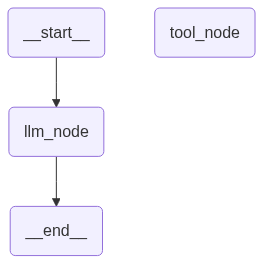

In [338]:
graph=StateGraph(graph_schema)
#Add nodes to the graph
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)

#Add edges between nodes
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",if_tool_call)# conditional edge for the tool call
graph.add_edge("tool_node","llm_node")# if it go to tool call then  I need to attach the edge (toolresponse edge)

react_graph=graph.compile()

from IPython.display import Image
Image(react_graph.get_graph().draw_mermaid_png())

In [339]:
# Right way Manually End and make perfect state graph

In [340]:
def if_tool_call(state:graph_schema)-> str:
  last_message=state['messages'][-1]
  if last_message.tool_calls: # when we need toolcall then
    return "tool_node"
  else:# when not need tool call the LLm is enough then
    return "end"


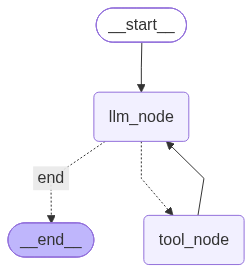

In [341]:
graph=StateGraph(graph_schema)
#Add nodes to the graph
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)

#Add edges between nodes
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",if_tool_call,{"tool_node":"tool_node","end":END})# conditional edge for the tool call
graph.add_edge("tool_node","llm_node")# if it go to tool call then  I need to attach the edge (toolresponse edge)

react_graph=graph.compile()

from IPython.display import Image
Image(react_graph.get_graph().draw_mermaid_png())

### **Graph Invocation**

In [342]:
react_graph.invoke({"messages":[HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'p6pm1f9ps', 'function': {'arguments': '{"query":"latest news on AI 2024"}', 'name': 'search_duckduckgo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 437, 'total_tokens': 473, 'completion_time': 0.108823776, 'completion_tokens_details': None, 'prompt_time': 0.030884488, 'prompt_tokens_details': None, 'queue_time': 0.005191072, 'total_time': 0.139708264}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_fea14bdc83', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a3ea-a8f5-7572-8bb9-32ad97cf5dc4-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI 2024'}, 'id': 'p6pm1f9ps', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

### Real time stuff example seen by streaming below

In [343]:
for chunk in react_graph.stream(
    {"messages":[HumanMessage(content="what is the latest news on AI")]},
    stream_node="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='what is the latest news on AI', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9g6jst8gn', 'function': {'arguments': '{"query":"latest news on AI"}', 'name': 'search_duckduckgo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 436, 'total_tokens': 467, 'completion_time': 0.087224249, 'completion_tokens_details': None, 'prompt_time': 0.036106625, 'prompt_tokens_details': None, 'queue_time': 0.024645965, 'total_time': 0.123330874}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_5e14805ce3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a3f2-9bc0-77a3-93fb-5415674c494e-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': '9g6jst8gn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t